In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Сразу переведем столбец "Дата" в правильный формат

In [16]:
print(df.info())

df['Дата'] = pd.to_datetime(df['Дата'])

print("\nОбновленные типы данных:")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB
None

Обновленные типы данных:
Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [20]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

grouped_df.columns = ['Дата', 'Количество продаж']

print(grouped_df.head())

        Дата  Количество продаж
0 2018-01-04               3734
1 2018-01-05               3643
2 2018-01-06               3193
3 2018-01-07               3298
4 2018-01-09               4055


Вывести несколько первых строк сгруппированных данных

In [23]:
print(grouped_df.head())

print(f"\nРазмер сгруппированных данных: {grouped_df.shape}")

        Дата  Количество продаж
0 2018-01-04               3734
1 2018-01-05               3643
2 2018-01-06               3193
3 2018-01-07               3298
4 2018-01-09               4055

Размер сгруппированных данных: (205, 2)


Нарисуйте график продаж у `grouped_df`

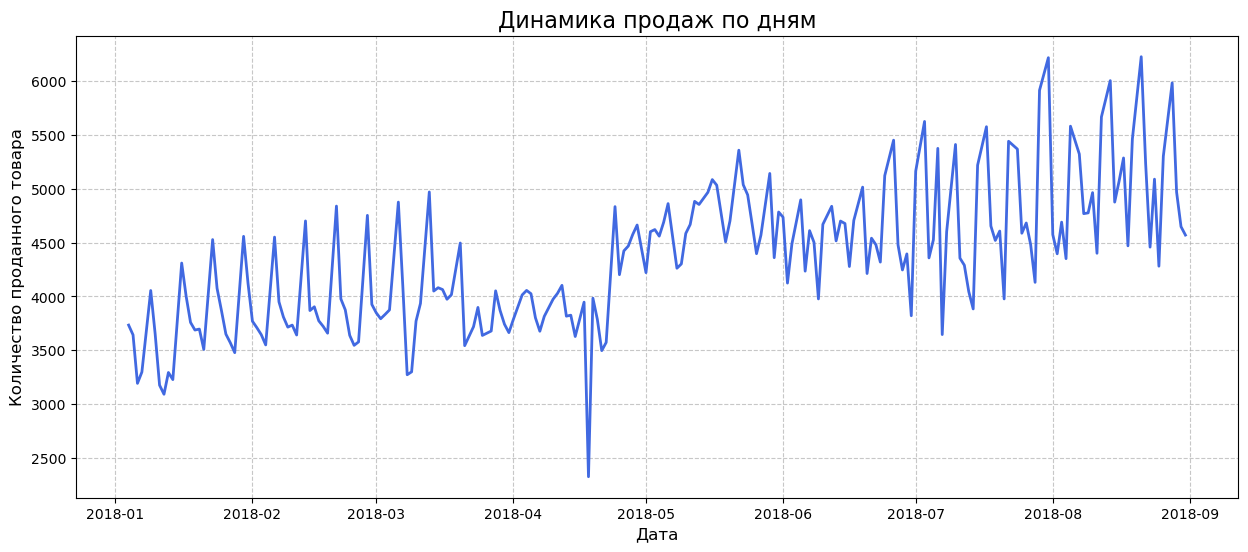

In [37]:
plt.figure(figsize=(15, 6))

plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'], color='royalblue', linewidth=2)

plt.title('Динамика продаж по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество проданного товара', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
- Ось X: Представляет временной период.
- Ось Y: Показывает суммарное количество проданного товара за конкретные сутки.
- График имеет «зубчатую» структуру. говорит о высокой ежедневной волатильности: продажи не стабильны, они постоянно колеблются.
- На графике отчетливо видны повторяющиеся колебания. 
- Если смотреть на график в разрезе месяцев, можно заметить, есть ли постепенный рост (позитивный тренд) или спад к концу периода.
- Это самый важный элемент для данной задачи. На фоне общих колебаний (которые обычно находятся в определенном коридоре, например, 
от 200 до 600 единиц) вы увидите резкий вертикальный пик.
- Этот пик — выброс. Он выглядит как «игла», которая уходит далеко вверх относительно основной массы данных. 
- Это означает, что в этот конкретный день произошло событие, не характерное для обычного режима работы 
(крупный оптовый заказ, ошибка в данных или супер-акция).
- Линия непрерывна на тех участках, где продажи шли каждый день. 
Если на графике есть «разрывы», это может указывать на праздничные дни или периоды, когда данные не записывались.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [43]:
outlier_row = df[df['Количество'] == df['Количество'].max()]

print("Строка с максимальным выбросом:")
outlier_row

Строка с максимальным выбросом:


,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [57]:
summer_wednesdays_3 = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
]

top_products = summer_wednesdays_3.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)

print("Топовые товары на 3-м складе (лето, среды):")
print(top_products.head(1))

Топовые товары на 3-м складе (лето, среды):
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

weather = pd.read_excel('погода.xls', skiprows=6)

weather = weather[['Местное время в Астане', 'T']]

weather['Дата'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True).dt.normalize()
weather_daily = weather.groupby('Дата')['T'].mean().reset_index()

merged_df = pd.merge(grouped_df, weather_daily, on='Дата', how='inner')

print("Первые строки объединенной таблицы:")
print(merged_df.head())

Первые строки объединенной таблицы:
        Дата  Количество продаж        T
0 2018-01-04               3734 -14.0750
1 2018-01-05               3643 -16.8625
2 2018-01-06               3193 -13.3000
3 2018-01-07               3298 -12.7500
4 2018-01-09               4055  -6.2500


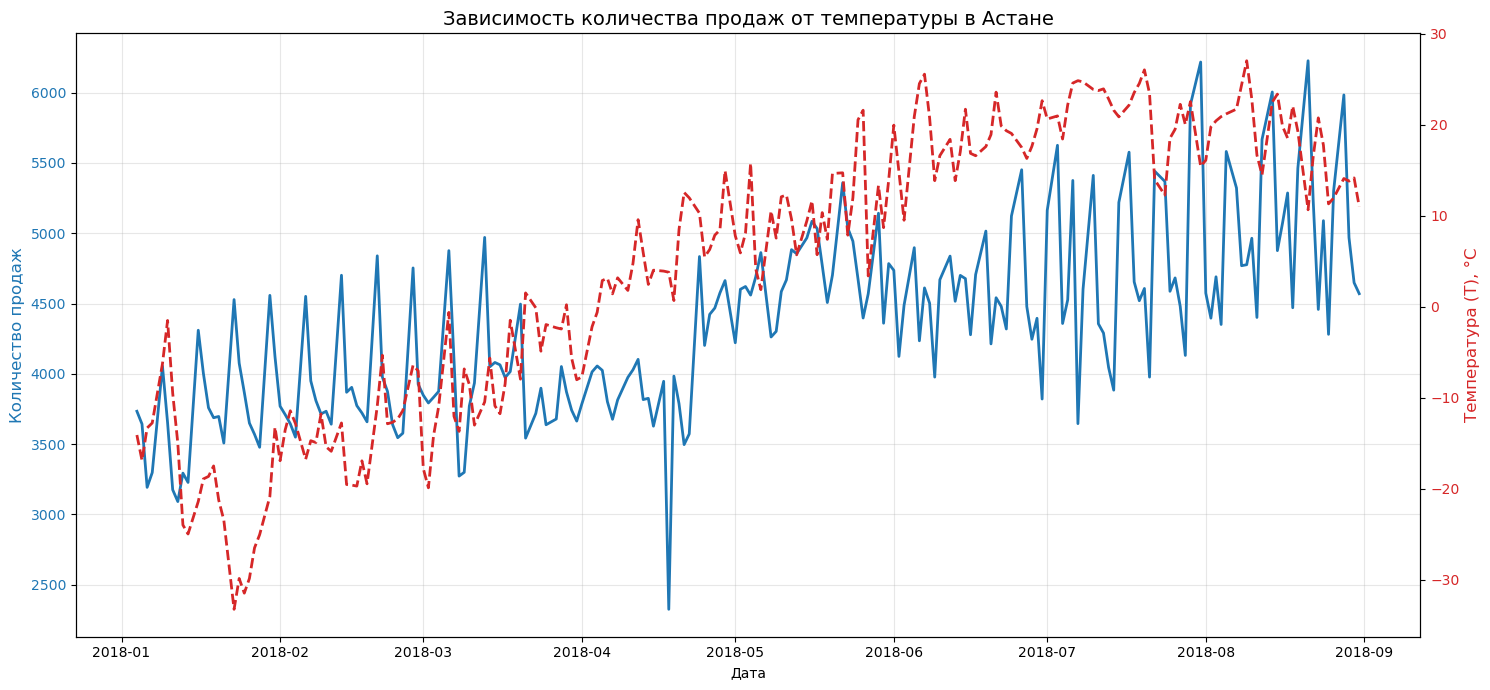

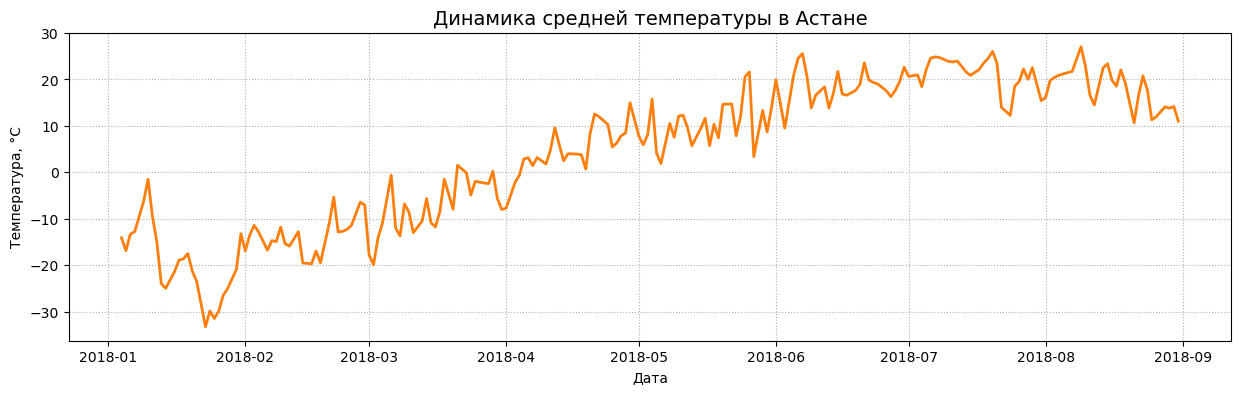

In [97]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(merged_df['Дата'], merged_df['Количество продаж'], color='tab:blue', label='Количество продаж', linewidth=2)
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], color='tab:red', label='Температура (T)', linewidth=2, linestyle='--')
ax2.set_ylabel('Температура (T), °C', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Зависимость количества продаж от температуры в Астане', fontsize=14)
fig.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='tab:orange', linewidth=2)
plt.title('Динамика средней температуры в Астане', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True, linestyle=':')
plt.show()